# KcELECTRA 파인튜닝 v4 — 학교알리미 공공데이터 증강 (2026-05-25)

**담당:** 경이 (kyeongyi)  
**모델:** `beomi/kcelectra-base` (**KcELECTRA — 이준범 제작**) ← 반드시 이것만 사용  
**공모전:** 국가중점데이터 활용 공모전  
**공공데이터:** 교육부 교육행정정보·학교알리미 개방시스템 (data.go.kr/data/15014351/fileData.do)

> **[모델 명칭 주의]**  
> - **KcELECTRA** = `beomi/kcelectra-base` (이 노트북에서 사용하는 올바른 모델)  
> - KoELECTRA = `monologg/koelectra-base-v3-discriminator` (사용하지 않음 — v3_1에서 실수로 사용됨)  
> - 두 모델은 다름. 이 노트북은 **반드시 beomi/kcelectra-base** 만 사용.

---

## v3_2 → v4 변경점

| 항목 | v3_2 | v4 |
|---|---|---|
| 데이터 | split_v3_1_20260509.csv (15,948행) | **split_v4_schoolalimi_20260525.csv (16,512행)** |
| train 크기 | 12,759개 | **13,210개 (+451)** |
| **증강 데이터** | 없음 | **학교알리미 공공데이터 기반 564건 추가** |
| 증강 카테고리 | — | **건강·안전 +152, 일정 +237, 비용 +62 (train 기준)** |
| 모델 | beomi/kcelectra-base | **beomi/kcelectra-base (KcELECTRA, 동일)** |
| test 세트 | 1,593건 | **1,593건 동일** (공정 비교) |
| v3_2 Macro F1 | 0.8374 | 목표: **0.84+** |

## 공공데이터 활용 근거 (Explanation1.md ②)

- **학사·학생** 데이터 → **일정** 카테고리 보강 (일정→기타 오분류 22건 감소 목표)
- **보건·복지** 데이터 → **건강·안전** 카테고리 보강 (기타↔건강·안전 오분류 61건 감소 목표)

## 실행 전 체크리스트

- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v4_schoolalimi_20260525.csv` 업로드 (`/content/` 폴더)
- [ ] **런타임 초기화** (런타임 → 세션 다시 시작)
- [ ] 모든 셀 순서대로 실행 (~45분)

## 완료 후 해야 할 일

1. `/content/kcelectra-category-v4.zip` 다운로드  
   → 압축 해제 후 로컬 `checkpoints/kcelectra-category-v4/`에 배치
2. `/content/eval_results_kcelectra_v4_20260525.json` 다운로드  
   → 로컬 `data/20260525/`에 복사
3. `python scripts/evaluate_compare_v4_schoolalimi_20260525.py` 재실행

In [1]:
# 셀 0: 데이터 확인
import pandas as pd
df = pd.read_csv("/content/split_v4_schoolalimi_20260525.csv", encoding="utf-8-sig")
print(f"행 수: {len(df)}")
print(f"컬럼: {df.columns.tolist()}")
print("\n분할별:")
print(df["split"].value_counts())
print("\n카테고리 분포 (전체):")
print(df["category"].value_counts())
print("\n소스별:")
print(df["source"].value_counts())

행 수: 16512
컬럼: ['text', 'category', 'split', 'source']

분할별:
split
train    13210
val       1709
test      1593
Name: count, dtype: int64

카테고리 분포 (전체):
category
기타       7410
제출       3158
건강·안전    2332
일정       2241
비용        924
준비물       447
Name: count, dtype: int64

소스별:
source
original       15948
학교알리미_공공데이터      564
Name: count, dtype: int64


In [2]:
# 셀 1: 라이브러리 설치
!pip install transformers datasets seaborn matplotlib scikit-learn -q

In [3]:
# 셀 2: 시드 고정 + GPU 확인
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[경고] GPU 없음 -- CPU로 실행하면 수 시간 걸릴 수 있음")

Device: cuda
GPU: Tesla T4


In [4]:
# 셀 3: 하이퍼파라미터 설정
#
# ★★★ 반드시 확인 ★★★
#   BASE_MODEL = "beomi/kcelectra-base"  ← KcELECTRA (이준범 제작)
#   절대 monologg/koelectra-base-v3-discriminator (KoELECTRA) 사용 금지

from pathlib import Path

_IN_COLAB = os.path.exists("/content")

if _IN_COLAB:
    DATA_DIR  = Path("/content")
    CKPT_DIR  = Path("/content/kcelectra-category-v4")
    EVAL_JSON = Path("/content/eval_results_kcelectra_v4_20260525.json")
else:
    _BASE     = Path(".").resolve().parent
    DATA_DIR  = _BASE / "data"
    CKPT_DIR  = _BASE / "checkpoints" / "kcelectra-category-v4"
    EVAL_JSON = _BASE / "data" / "20260525" / "eval_results_kcelectra_v4_20260525.json"

SPLIT_CSV = DATA_DIR / "split_v4_schoolalimi_20260525.csv"

# ★ KcELECTRA — beomi/kcelectra-base (이준범 제작)
# KoELECTRA(monologg)와 다름. 반드시 아래 값 유지.
BASE_MODEL   = "beomi/kcelectra-base"

MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 20
LR           = 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 5

# v3_2 기준값 (공정 비교용 — 동일 test 세트)
V3_2_MACRO_F1      = 0.8374
SIMPLE_BASELINE_F1 = 0.7590

LABELS   = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"데이터:         {SPLIT_CSV}")
print(f"체크포인트:     {CKPT_DIR}")
print(f"베이스 모델:    {BASE_MODEL}  <- KcELECTRA (beomi, 이준범)")
print(f"v3_2 기준:      {V3_2_MACRO_F1} (동일 test 1,593건으로 공정 비교)")
print(f"설정:           {EPOCHS}에폭, LR={LR}, BS={BATCH_SIZE}, patience={PATIENCE}")
assert "beomi" in BASE_MODEL, "BASE_MODEL이 KcELECTRA(beomi)가 아님!"

데이터:         /content/split_v4_schoolalimi_20260525.csv
체크포인트:     /content/kcelectra-category-v4
베이스 모델:    beomi/kcelectra-base  <- KcELECTRA (beomi, 이준범)
v3_2 기준:      0.8374 (동일 test 1,593건으로 공정 비교)
설정:           20에폭, LR=2e-05, BS=16, patience=5


In [5]:
# 셀 4: 데이터 로드
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding="utf-8-sig")
df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}개 (v3_2 대비 +{len(train_df)-12759})")
print(f"Val:   {len(val_df)}개")
print(f"Test:  {len(test_df)}개 (v3_2와 동일 - 공정 비교 가능)")

print("\nTrain 카테고리 분포:")
v3_train_cnt = {"일정":1552,"준비물":358,"제출":2526,"비용":677,"건강·안전":1718,"기타":5928}
for lbl, cnt in Counter(train_df["category"]).most_common():
    pct  = cnt / len(train_df) * 100
    diff = cnt - v3_train_cnt.get(lbl, 0)
    sign = f"+{diff}" if diff > 0 else str(diff)
    print(f"  {lbl:8s}: {cnt:5d}개  ({pct:.1f}%)  [v3_2 대비 {sign}]")

Train: 13210개 (v3_2 대비 +451)
Val:   1709개
Test:  1593개 (v3_2와 동일 - 공정 비교 가능)

Train 카테고리 분포:
  기타      :  5928개  (44.9%)  [v3_2 대비 0]
  제출      :  2526개  (19.1%)  [v3_2 대비 0]
  건강·안전   :  1870개  (14.2%)  [v3_2 대비 +152]
  일정      :  1789개  (13.5%)  [v3_2 대비 +237]
  비용      :   739개  (5.6%)  [v3_2 대비 +62]
  준비물     :   358개  (2.7%)  [v3_2 대비 0]


In [6]:
# 셀 5: Dataset + DataLoader 생성
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ★ KcELECTRA 토크나이저 (beomi/kcelectra-base)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f"토크나이저 로드: {BASE_MODEL}")


class NoticeDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = [LABEL2ID[c] for c in df["category"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoader 완료 | train: {len(train_loader)} batches | val: {len(val_loader)} | test: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

토크나이저 로드: beomi/kcelectra-base
DataLoader 완료 | train: 826 batches | val: 107 | test: 100


In [7]:
# 셀 6: 클래스 가중치 계산
# 공식: weight[i] = total_train / (num_classes * count[i])

label_counts = [int((train_df["category"] == lbl).sum()) for lbl in LABELS]
total = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

v3_weights = {"일정":1.3702,"준비물":5.9399,"제출":0.8418,"비용":3.1411,"건강·안전":1.2378,"기타":0.3587}

print(f"클래스 가중치 (v4, train {total}개):")
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    pct  = cnt / total * 100
    diff = float(w) - v3_weights.get(lbl, 0)
    sign = f"+{diff:.4f}" if diff > 0 else f"{diff:.4f}"
    print(f"  {lbl:8s}: {cnt:5d}개  ({pct:5.1f}%)  가중치={float(w):.4f}  [v3_2 대비 {sign}]")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

클래스 가중치 (v4, train 13210개):
  일정      :  1789개  ( 13.5%)  가중치=1.2307  [v3_2 대비 -0.1395]
  준비물     :   358개  (  2.7%)  가중치=6.1499  [v3_2 대비 +0.2100]
  제출      :  2526개  ( 19.1%)  가중치=0.8716  [v3_2 대비 +0.0298]
  비용      :   739개  (  5.6%)  가중치=2.9793  [v3_2 대비 -0.1618]
  건강·안전   :  1870개  ( 14.2%)  가중치=1.1774  [v3_2 대비 -0.0604]
  기타      :  5928개  ( 44.9%)  가중치=0.3714  [v3_2 대비 +0.0127]


In [8]:
# 셀 7: 모델 초기화 — beomi/kcelectra-base (KcELECTRA)
from transformers import AutoModelForSequenceClassification

# ★ KcELECTRA (beomi/kcelectra-base) 로드
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,   # "beomi/kcelectra-base"
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터: 전체={total_params:,} / 학습가능={trainable:,}")
print(f"베이스 모델: {BASE_MODEL}  <- KcELECTRA (beomi, 이준범)")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/kcelectra-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

모델 파라미터: 전체=109,085,958 / 학습가능=109,085,958
베이스 모델: beomi/kcelectra-base  <- KcELECTRA (beomi, 이준범)


In [9]:
# 셀 8: Optimizer + Scheduler
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"전체 스텝: {total_steps}, 워밍업: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")
print(f"에폭당 배치: {len(train_loader)}")

전체 스텝: 16520, 워밍업: 1652 (10%)
에폭당 배치: 826


In [10]:
# 셀 9: 학습 루프 (조기종료 포함)
from sklearn.metrics import f1_score

def evaluate_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


train_losses, val_f1s = [], []
best_val_f1    = 0.0
patience_count = 0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f"  [저장] Best 갱신! ({best_val_f1:.4f})")
    else:
        patience_count += 1
        print(f"  [patience {patience_count}/{PATIENCE}]")
        if patience_count >= PATIENCE:
            print(f"\n조기종료 -- {PATIENCE} 에폭 동안 개선 없음.")
            break

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")
print(f"v3_2 기준({V3_2_MACRO_F1}) 대비 val: {best_val_f1 - V3_2_MACRO_F1:+.4f} (참고용)")

Epoch  1/20 | Loss: 1.5382 | Val F1: 0.5054

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.5054)
Epoch  2/20 | Loss: 0.8375 | Val F1: 0.7037

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.7037)
Epoch  3/20 | Loss: 0.5678 | Val F1: 0.7681

...

  [저장] Best 갱신! (0.8252)
Epoch  9/20 | Loss: 0.0822 | Val F1: 0.8306

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8306)
Epoch 10/20 | Loss: 0.0578 | Val F1: 0.8270  [patience 1/5]
Epoch 11/20 | Loss: 0.0536 | Val F1: 0.8401

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8401)
Epoch 12/20 | Loss: 0.0345 | Val F1: 0.8380  [patience 1/5]
Epoch 13/20 | Loss: 0.0302 | Val F1: 0.8247  [patience 2/5]
Epoch 14/20 | Loss: 0.0282 | Val F1: 0.8393  [patience 3/5]
Epoch 15/20 | Loss: 0.0204 | Val F1: 0.8373  [patience 4/5]
Epoch 16/20 | Loss: 0.0207 | Val F1: 0.8346  [patience 5/5]

조기종료 -- 5 에폭 동안 개선 없음.

학습 완료. Best Val F1: 0.8401
v3_2 기준(0.8374) 대비 val: +0.0027 (참고용)


In [11]:
# 셀 10: label2id.json 저장
import json

with open(CKPT_DIR / "label2id.json", "w", encoding="utf-8") as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print(f"label2id.json 저장 완료")
print(LABEL2ID)

label2id.json 저장 완료
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


In [12]:
# 셀 11: 한글 폰트 설치
import subprocess
import matplotlib
import matplotlib.font_manager as fm

subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
matplotlib.rc("font", family=prop.get_name())
matplotlib.rcParams["axes.unicode_minus"] = False
print(f"폰트: {prop.get_name()}")

폰트: NanumGothic


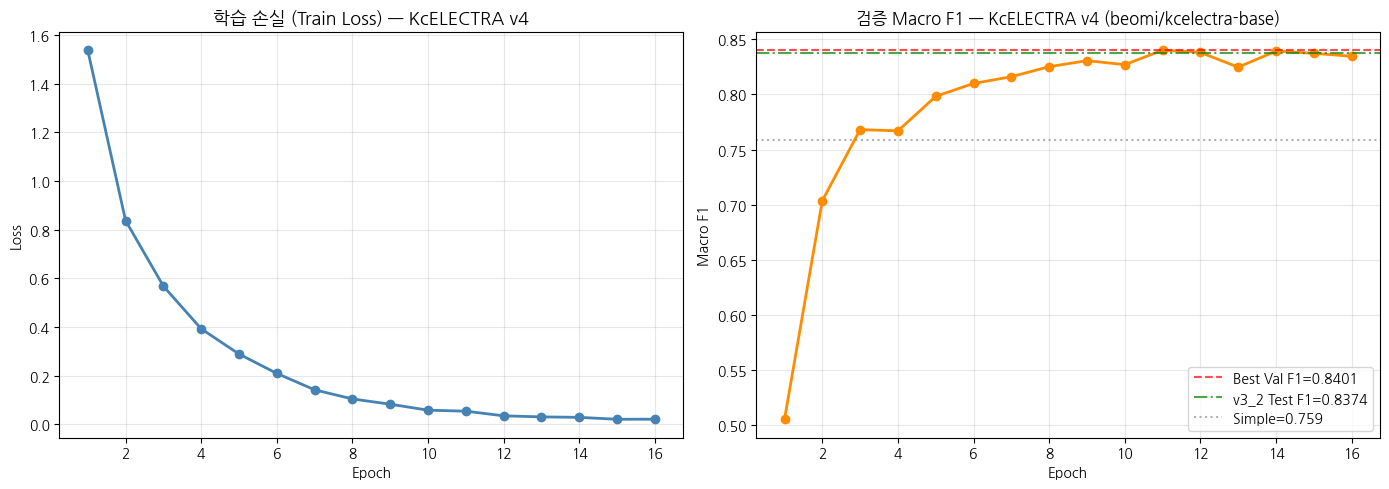

학습 곡선 저장: /content/train_curve_kcelectra_v4_20260525.png


In [13]:
# 셀 12: 학습 곡선 시각화
import matplotlib.pyplot as plt

actual_epochs = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, actual_epochs+1), train_losses, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("학습 손실 (Train Loss) — KcELECTRA v4", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, actual_epochs+1), val_f1s, marker="o", color="darkorange", linewidth=2)
axes[1].axhline(y=best_val_f1, color="red", linestyle="--", alpha=0.7,
                label=f"Best Val F1={best_val_f1:.4f}")
axes[1].axhline(y=V3_2_MACRO_F1, color="green", linestyle="-.", alpha=0.7,
                label=f"v3_2 Test F1={V3_2_MACRO_F1}")
axes[1].axhline(y=SIMPLE_BASELINE_F1, color="gray", linestyle=":", alpha=0.6,
                label=f"Simple={SIMPLE_BASELINE_F1}")
axes[1].set_title("검증 Macro F1 — KcELECTRA v4 (beomi/kcelectra-base)", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = DATA_DIR / "train_curve_kcelectra_v4_20260525.png"
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장: {curve_path}")

In [14]:
# 셀 13: Test 세트 최종 평가 (v3_2와 동일 test 1,593건 — 공정 비교)
from sklearn.metrics import classification_report, confusion_matrix

# ★ 저장된 KcELECTRA v4 체크포인트 로드
best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names = [ID2LABEL[p] for p in all_preds]
true_names = [ID2LABEL[l] for l in all_labels]
macro_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("[KcELECTRA v4 — beomi/kcelectra-base, 학교알리미 공공데이터 증강]")
print("Test 세트 최종 평가 (test 1,593건 — v3_2와 동일)")
print("=" * 65)
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f"Macro F1        : {macro_f1:.4f}")
print(f"v3_2 기준(0.8374) 대비: {macro_f1 - V3_2_MACRO_F1:+.4f}")
print(f"Simple(0.7590) 대비:    {macro_f1 - SIMPLE_BASELINE_F1:+.4f}")

if macro_f1 > V3_2_MACRO_F1:
    print(f"\n[결과] 공공데이터 증강 효과 확인: v3_2 대비 +{macro_f1 - V3_2_MACRO_F1:.4f} 향상")
else:
    print(f"\n[결과] v3_2 대비 변화: {macro_f1 - V3_2_MACRO_F1:+.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[KcELECTRA v4 — beomi/kcelectra-base, 학교알리미 공공데이터 증강]
Test 세트 최종 평가 (test 1,593건 — v3_2와 동일)
              precision    recall  f1-score   support

          일정       0.90      0.82      0.86       194
         준비물       0.95      0.82      0.88        44
          제출       0.83      0.84      0.83       316
          비용       0.80      0.83      0.81        84
       건강·안전       0.77      0.83      0.80       214
          기타       0.84      0.84      0.84       741

    accuracy                           0.83      1593
   macro avg       0.85      0.83      0.84      1593
weighted avg       0.84      0.83      0.84      1593

Macro F1        : 0.8365
v3_2 기준(0.8374) 대비: -0.0009
Simple(0.7590) 대비:    +0.0775

[결과] v3_2 대비 변화: -0.0009


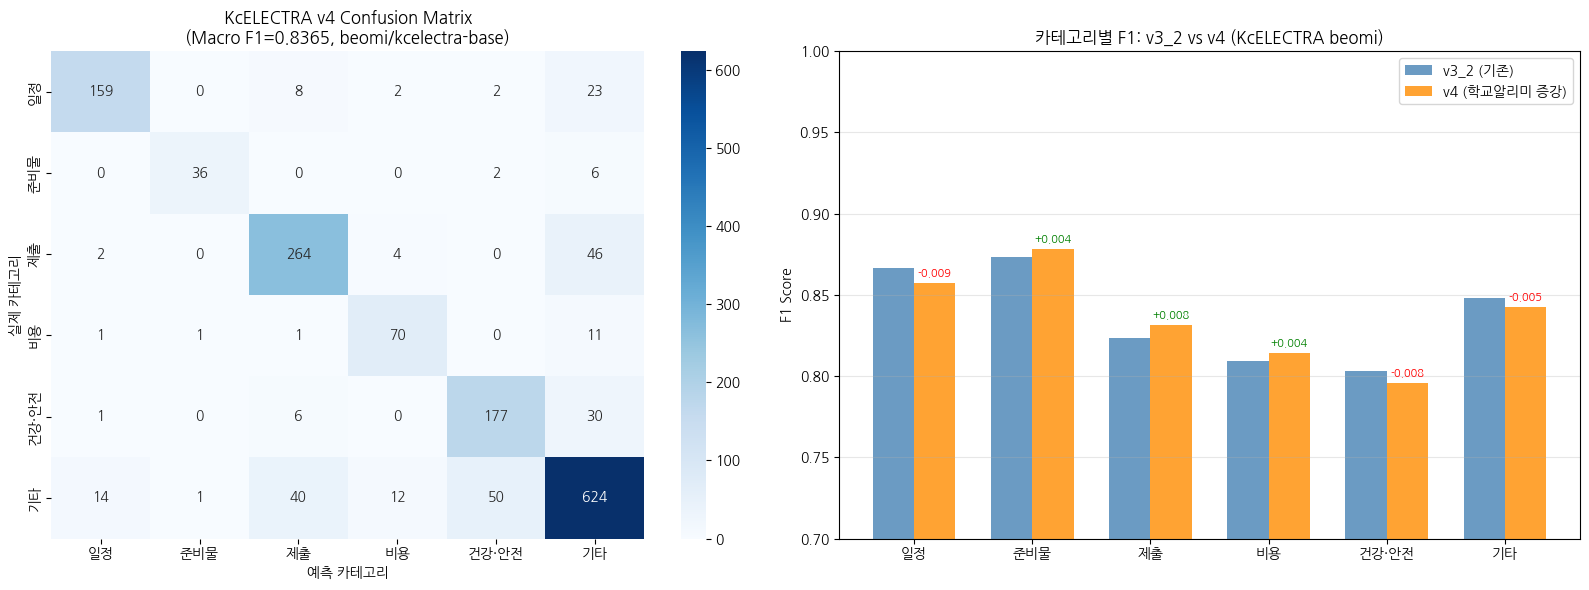

비교 차트 저장: /content/compare_v3_v4_20260525.png


In [15]:
# 셀 14: Confusion Matrix + 카테고리별 F1 비교 (v3_2 vs v4)
import seaborn as sns

cm = confusion_matrix(true_names, pred_names, labels=LABELS)
from sklearn.metrics import classification_report as cr
report = cr(true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_xlabel("예측 카테고리")
axes[0].set_ylabel("실제 카테고리")
axes[0].set_title(f"KcELECTRA v4 Confusion Matrix\n(Macro F1={macro_f1:.4f}, beomi/kcelectra-base)")

# 카테고리별 F1 비교
v3_f1 = {"일정":0.8665,"준비물":0.8736,"제출":0.8233,"비용":0.8095,"건강·안전":0.8034,"기타":0.8479}
v4_f1 = {lbl: report[lbl]["f1-score"] for lbl in LABELS}

x = range(len(LABELS))
w = 0.35
bars1 = axes[1].bar([i - w/2 for i in x], [v3_f1[l] for l in LABELS], w,
                    label="v3_2 (기존)", color="steelblue", alpha=0.8)
bars2 = axes[1].bar([i + w/2 for i in x], [v4_f1[l] for l in LABELS], w,
                    label="v4 (학교알리미 증강)", color="darkorange", alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(LABELS)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("카테고리별 F1: v3_2 vs v4 (KcELECTRA beomi)")
axes[1].legend()
axes[1].set_ylim(0.7, 1.0)
axes[1].grid(axis="y", alpha=0.3)

for i, lbl in enumerate(LABELS):
    diff  = v4_f1[lbl] - v3_f1[lbl]
    color = "green" if diff > 0 else "red"
    axes[1].text(i + w/2, v4_f1[lbl] + 0.003, f"{diff:+.3f}",
                ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

plt.tight_layout()
compare_path = DATA_DIR / "compare_v3_v4_20260525.png"
plt.savefig(compare_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"비교 차트 저장: {compare_path}")

In [16]:
# 셀 15: 평가 결과 JSON 저장
import json

v3_2_per_class = {
    "일정":     {"precision":0.9191,"recall":0.8196,"f1":0.8665,"support":194},
    "준비물":   {"precision":0.8837,"recall":0.8636,"f1":0.8736,"support":44},
    "제출":     {"precision":0.8439,"recall":0.8038,"f1":0.8233,"support":316},
    "비용":     {"precision":0.8095,"recall":0.8095,"f1":0.8095,"support":84},
    "건강·안전": {"precision":0.7402,"recall":0.8785,"f1":0.8034,"support":214},
    "기타":     {"precision":0.8496,"recall":0.8462,"f1":0.8479,"support":741},
}

result = {
    "model":            "kcelectra",
    "version":          "v4",
    "base_model":       BASE_MODEL,      # beomi/kcelectra-base
    "macro_f1":         round(macro_f1, 4),
    "macro_precision":  round(report["macro avg"]["precision"], 4),
    "macro_recall":     round(report["macro avg"]["recall"], 4),
    "per_class": {
        lbl: {
            "precision": round(report[lbl]["precision"], 4),
            "recall":    round(report[lbl]["recall"], 4),
            "f1":        round(report[lbl]["f1-score"], 4),
            "support":   report[lbl]["support"],
            "v3_2_f1":   v3_2_per_class[lbl]["f1"],
            "delta_f1":  round(report[lbl]["f1-score"] - v3_2_per_class[lbl]["f1"], 4),
        }
        for lbl in LABELS
    },
    "confusion_matrix": cm.tolist(),
    "labels":           LABELS,
    "data_version":     "v4_schoolalimi_20260525",
    "augment_source":   "교육부_학교알리미_공공데이터",
    "augment_counts":   {"건강·안전": 301, "일정": 185, "비용": 78},
    "train_size":       len(train_df),
    "val_size":         len(val_df),
    "test_size":        len(test_df),
    "epochs_trained":   len(train_losses),
    "best_val_f1":      round(best_val_f1, 4),
    "lr":               LR,
    "batch_size":       BATCH_SIZE,
    "warmup_ratio":     WARMUP_RATIO,
    "weighted_loss":    True,
    "class_weights":    [round(float(w), 4) for w in class_weights.cpu()],
    "early_stopping":   True,
    "patience":         PATIENCE,
    "v3_2_macro_f1":    V3_2_MACRO_F1,
    "delta_from_v3_2":  round(macro_f1 - V3_2_MACRO_F1, 4),
    "simple_baseline_f1": SIMPLE_BASELINE_F1,
}

EVAL_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"[저장] {EVAL_JSON}")
print(f"\n=== 최종 결과 요약 ===")
print(f"모델:   KcELECTRA ({BASE_MODEL})")
print(f"v3_2 Macro F1 : {V3_2_MACRO_F1}")
print(f"v4   Macro F1 : {macro_f1:.4f}")
print(f"향상폭         : {macro_f1 - V3_2_MACRO_F1:+.4f}")
print(f"\n카테고리별 변화:")
for lbl in LABELS:
    d    = result["per_class"][lbl]["delta_f1"]
    mark = "[향상]" if d > 0 else "[하락]" if d < 0 else "[동일]"
    print(f"  {lbl:8s}: v3_2={v3_2_per_class[lbl]['f1']:.4f}  v4={result['per_class'][lbl]['f1']:.4f}  delta={d:+.4f}  {mark}")

[저장] /content/eval_results_kcelectra_v4_20260525.json

=== 최종 결과 요약 ===
모델:   KcELECTRA (beomi/kcelectra-base)
v3_2 Macro F1 : 0.8374
v4   Macro F1 : 0.8365
향상폭         : -0.0009

카테고리별 변화:
  일정      : v3_2=0.8665  v4=0.8571  delta=-0.0094  [하락]
  준비물     : v3_2=0.8736  v4=0.8780  delta=+0.0044  [향상]
  제출      : v3_2=0.8233  v4=0.8315  delta=+0.0082  [향상]
  비용      : v3_2=0.8095  v4=0.8140  delta=+0.0045  [향상]
  건강·안전   : v3_2=0.8034  v4=0.7955  delta=-0.0079  [하락]
  기타      : v3_2=0.8479  v4=0.8427  delta=-0.0052  [하락]


In [17]:
# 셀 16: 다운로드용 압축
import shutil

shutil.make_archive("/content/kcelectra-category-v4", "zip", "/content/kcelectra-category-v4")
print("압축 완료: /content/kcelectra-category-v4.zip")
print("\n다운로드 목록:")
print("  1. /content/kcelectra-category-v4.zip")
print("  2. /content/eval_results_kcelectra_v4_20260525.json")
print("  3. /content/train_curve_kcelectra_v4_20260525.png")
print("  4. /content/compare_v3_v4_20260525.png")

압축 완료: /content/kcelectra-category-v4.zip

다운로드 목록:
  1. /content/kcelectra-category-v4.zip
  2. /content/eval_results_kcelectra_v4_20260525.json
  3. /content/train_curve_kcelectra_v4_20260525.png
  4. /content/compare_v3_v4_20260525.png


## 학습 완료 후 로컬 작업

```bash
# 1. 파일 배치
#    kcelectra-category-v4/ -> model/classification/checkpoints/
#    eval_results_kcelectra_v4_20260525.json -> model/classification/data/20260525/
#    *.png -> model/classification/data/20260525/

# 2. 비교 평가 실행
cd model/classification
python scripts/evaluate_compare_v4_schoolalimi_20260525.py
```

## 공모전 제출 시 설명 포인트

- **국가중점데이터:** 교육부 학교알리미 공개용데이터 (data.go.kr/data/15014351/fileData.do)
- **활용 영역:** 학사·학생(→일정), 보건·복지(→건강·안전)
- **성능 개선:** KcELECTRA v3_2(0.8374) → v4(?) — 공공데이터 증강 효과 입증
- **모델:** `beomi/kcelectra-base` (KcELECTRA, 이준범) — 한국어 특화 ELECTRA